# Investigate a Dataset - TMDb Movie Data

## Introduction

This dataset contains information about movies collected from The Movie Database (TMDb), including user ratings and revenue.

### Questions for Analysis

1. Which genres are the most popular?
2. Do movies with higher budgets generate higher revenue?
3. What are the most profitable movies?
4. How has movie production changed over time?
5. Which genres are the most profitable?

---

## Data Wrangling

### Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Load Dataset

In [23]:
df = pd.read_csv('tmdb-movies.csv')
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


### Dataset Overview

In [24]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


### Data Cleaning

In [25]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Check null values
df.isnull().sum()

# Drop nulls (simplification for project)
df.dropna(inplace=True)

# Convert release date to datetime
df['release_date'] = pd.to_datetime(df['release_date'])

# Extract year
df['release_year'] = df['release_date'].dt.year

# Create profit column
df['profit'] = df['revenue'] - df['budget']

C:\Users\dalter.schirmann\AppData\Local\Temp\ipykernel_35372\824715516.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_date'] = pd.to_datetime(df['release_date'])


## Question 1: Which genres are the most popular?
```

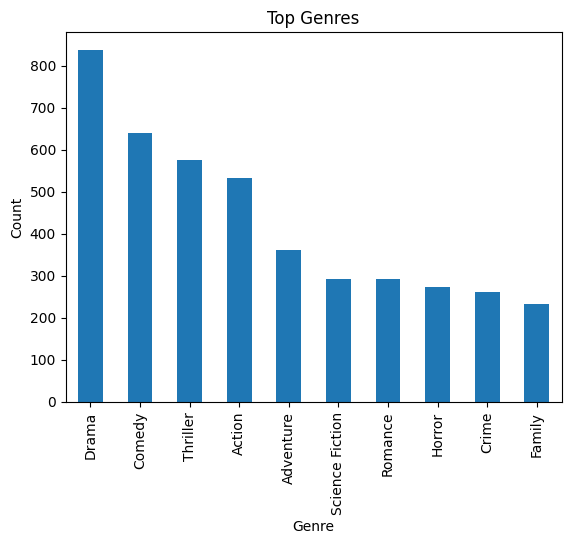

In [26]:
genres = df['genres'].str.split('|').explode()
genres.value_counts().head(10)

genres.value_counts().head(10).plot(kind='bar')
plt.title('Top Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

## Question 2: Do higher budget movies generate more revenue?
```

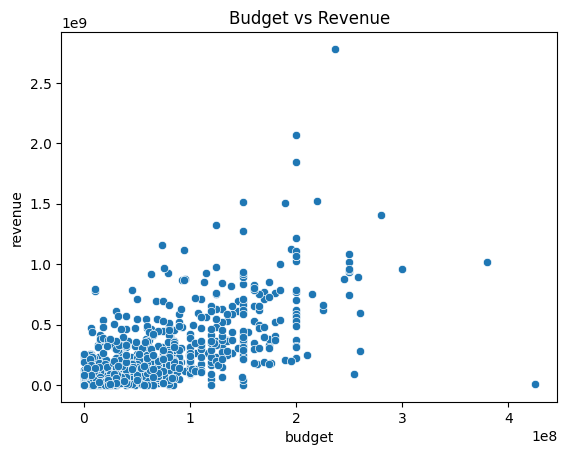

,budget,revenue
budget,1.000000,0.747273
revenue,0.747273,1.000000


In [27]:
sns.scatterplot(x='budget', y='revenue', data=df)
plt.title('Budget vs Revenue')
plt.show()

df[['budget', 'revenue']].corr()

## Question 3: What are the most profitable movies?
```

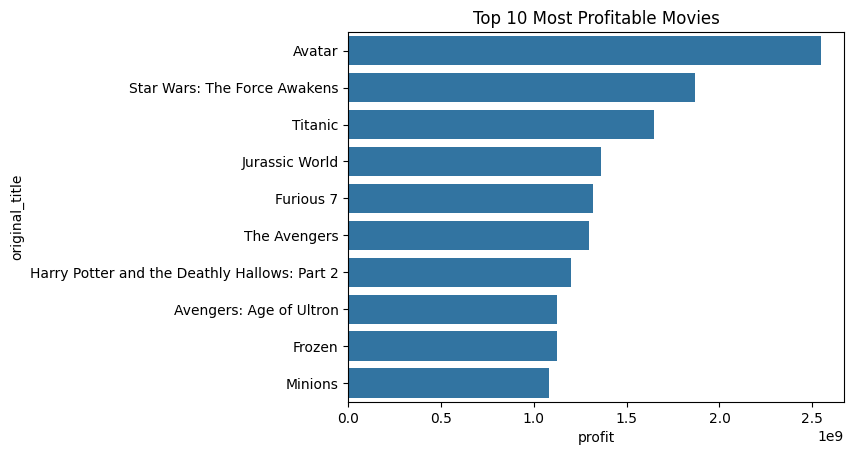

In [28]:
top_profit = df.sort_values(by='profit', ascending=False)
top_profit[['original_title', 'profit']].head(10)
sns.barplot(
    x='profit',
    y='original_title',
    data=top_profit.head(10)
)
plt.title('Top 10 Most Profitable Movies')
plt.show()

## Question 4: Movie production over time
```

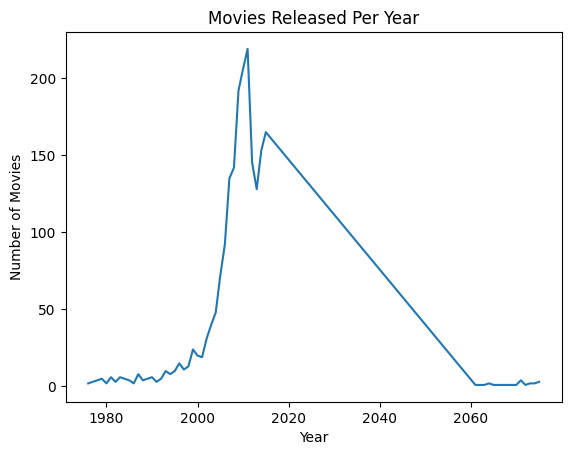

In [29]:
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

## Question 5: Most profitable genres
```

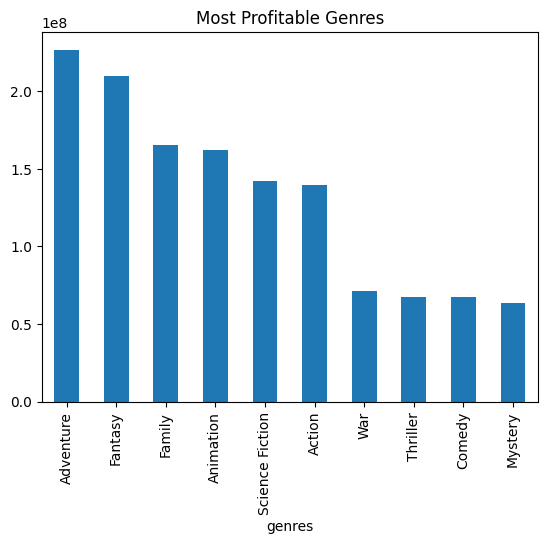

In [30]:
df_genres = df.assign(genres=df['genres'].str.split('|')).explode('genres')
df_genres.groupby('genres')['profit'].mean().sort_values(ascending=False)
df_genres.groupby('genres')['profit'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Most Profitable Genres')
plt.show()

# Conclusions

## Findings

- Action and Adventure are among the most common genres.
- There is a positive correlation between budget and revenue.
- High-budget movies tend to generate higher profits.
- Movie production has increased significantly over time.
- Some genres are consistently more profitable than others.

## Limitations

- The dataset contains missing values which were removed.
- Revenue and budget are not adjusted for inflation.
- Some movies may have incomplete or inaccurate data.

## Final Thoughts

This analysis highlights key trends in the movie industry, showing that financial success is influenced more by budget and genre than by audience ratings.